In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

BASE = os.path.abspath("..")
FIG = os.path.join(BASE, "outputs", "figures")
PROC = os.path.join(BASE, "data", "processed")
RAW = os.path.join(BASE, "data", "raw")

d = pd.read_csv(os.path.join(PROC, "dhaka_clean.csv"), parse_dates=["datetime", "datetime_local"])
w = pd.read_csv(os.path.join(RAW, "weather_dhaka.csv"), parse_dates=["datetime"])
df = d.merge(w, on="datetime", how="inner")

daily = df.set_index("datetime_local").resample("D").agg({
    "pm2_5": "mean",
    "temperature_2m": "mean",
    "relative_humidity_2m": "mean",
    "precipitation": "sum",
    "wind_speed_10m": "mean",
})
daily = daily.iloc[1:-1]   # প্রথম ও শেষ আংশিক দিন বাদ
print(daily.shape, daily.index.min(), daily.index.max())

(1207, 5) 2022-08-05 00:00:00 2025-11-23 00:00:00


In [2]:
f = daily.copy()
f["lag1"] = f["pm2_5"].shift(1)
f["lag2"] = f["pm2_5"].shift(2)
f["lag7"] = f["pm2_5"].shift(7)
f["roll7"] = f["pm2_5"].shift(1).rolling(7).mean()

doy = f.index.dayofyear
f["sin_doy"] = np.sin(2 * np.pi * doy / 365.25)
f["cos_doy"] = np.cos(2 * np.pi * doy / 365.25)
f = f.dropna()

train = f[f.index < "2024-12-01"]
test = f[f.index >= "2024-12-01"]
print(len(train), len(test))

842 358


In [3]:
target = "pm2_5"
feat_a = ["lag1", "lag2", "lag7", "roll7", "sin_doy", "cos_doy"]
feat_b = feat_a + ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"]

def score(y, p):
    return {"MAE": round(mean_absolute_error(y, p), 2),
            "RMSE": round(np.sqrt(mean_squared_error(y, p)), 2),
            "R2": round(r2_score(y, p), 3)}

results = {}
results["Persistence (yesterday)"] = score(test[target], test["lag1"])

m_a = GradientBoostingRegressor(random_state=1).fit(train[feat_a], train[target])
pred_a = m_a.predict(test[feat_a])
results["GBM: lags + season"] = score(test[target], pred_a)

m_b = GradientBoostingRegressor(random_state=1).fit(train[feat_b], train[target])
pred_b = m_b.predict(test[feat_b])
results["GBM: + weather"] = score(test[target], pred_b)

pd.DataFrame(results).T

,MAE,RMSE,R2
Persistence (yesterday),9.84,14.87,0.827
GBM: lags + season,10.41,15.18,0.820
GBM: + weather,9.74,13.53,0.857


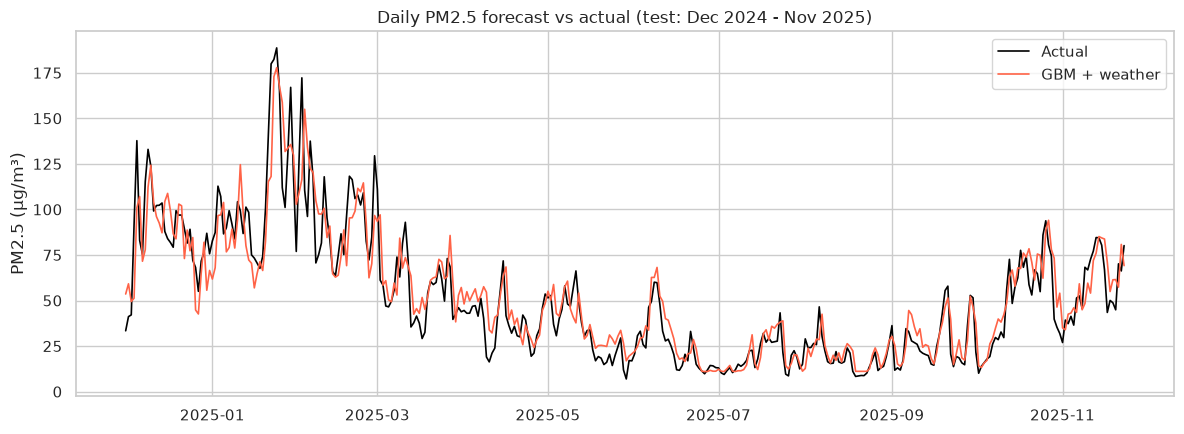

In [4]:
plt.figure(figsize=(12, 4.5))
plt.plot(test.index, test[target], label="Actual", color="black", lw=1.2)
plt.plot(test.index, pred_b, label="GBM + weather", color="tomato", lw=1.2)
plt.title("Daily PM2.5 forecast vs actual (test: Dec 2024 - Nov 2025)")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "forecast_vs_actual.png"), dpi=150)
plt.show()